# Neural Network Fraud Detection Model

This notebook evaluates a feedforward neural network for mule account detection.

Unlike tree-based models, neural networks can learn complex nonlinear relationships between engineered fraud indicators and account behavior.

The objective is to determine whether deep learning can identify fraud patterns missed by gradient boosting methods.

In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv("../data/raw/DataSet.csv")

import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    average_precision_score
)

## Feature Engineering

The feature set includes both original dataset variables and engineered fraud indicators derived from exploratory analysis.

These features capture fraud clusters, high-risk behavioral regions, interaction effects, and missing-value patterns.

In [3]:
df["F115_high"] = (df["F115"] > 0.78).astype(int)

df["F2582_hot"] = (
    (df["F2582"] > -0.03)
    & (df["F2582"] <= 0)
).astype(int)

df["F2956_hot"] = (
    (df["F2956"] > 19)
    & (df["F2956"] <= 32)
).astype(int)

df["F531_hot"] = (
    (df["F531"] > 0.95)
    & (df["F531"] <= 1.35)
).astype(int)

df["F2737_safe"] = (
    (df["F2737"] > 0)
    & (df["F2737"] <= 0.04)
).astype(int)

df["F2582_F531"] = (
    df["F2582_hot"]
    & df["F531_hot"]
).astype(int)

df["fraud_cluster_1"] = (
    df["F2582_hot"]
    & df["F2956_hot"]
    & df["F531_hot"]
).astype(int)

df["f3836_hot"] = (
    (df["F3836"] > 148.596 ) &
    (df["F3836"] <= 20077.212)
).astype(int)

df["F2956_F115"] = (
    df["F2956_hot"] &
    df["F115_high"]
).astype(int)

df["F2582_pos_F2956_low"] = (
    (df["F2582"] > 0.15) &
    (df["F2956"] < 60)
).astype(int)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15424\3734788897.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["F115_high"] = (df["F115"] > 0.78).astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15424\3734788897.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["F2582_hot"] = (
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15424\3734788897.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

In [4]:
features = [
    "F115",
    "F2582",
    "F2956",
    "F531",
    "F2737",
    "F670",
    "F673",
    "F3891",
    "F3889",

    # engineered features

    "F115_high",
    "F2582_hot",
    "F2956_hot",
    "F531_hot",
    "F2737_safe",
    "F2582_F531",
    "fraud_cluster_1",
    "f3836_hot",
    "F2956_F115",
    "F2582_pos_F2956_low"

]

family_cols = [
    "F664","F665","F666",
    "F667","F668","F669",
    "F670","F671","F672",
    "F673","F674","F675",

    "F1","F2","F3","F4","F5","F6","F7","F8","F9","F10","F12"
]

for col in family_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)

features += [f"{col}_missing" for col in family_cols]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15424\437142712.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_missing"] = df[col].isna().astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15424\437142712.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_missing"] = df[col].isna().astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15424\437142712.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [5]:
X = pd.get_dummies(
    df[features],
    columns=["F3891", "F3889"],
    dummy_na=True
)

y = df["F3924"]

## Data Preparation

Categorical variables are encoded using one-hot encoding and the dataset is split using stratified sampling.

The fraud prevalence is preserved across training and testing datasets.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = X_train.fillna(-999)
X_test = X_test.fillna(-999)

In [7]:
X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

## Missing Value Handling

Neural networks cannot directly process missing values.

Missing observations are therefore replaced with a constant placeholder value prior to scaling.

In [8]:
X_train_nn = X_train_nn.fillna(-999)
X_test_nn = X_test_nn.fillna(-999)

## Feature Scaling

Neural networks are sensitive to feature magnitudes.

All numerical inputs are standardized using StandardScaler to improve optimization stability and convergence.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_nn)
X_test_scaled = scaler.transform(X_test_nn)

## Class Imbalance Handling

Fraudulent accounts represent a very small fraction of the dataset.

Class weights are computed and applied during training to increase the penalty associated with misclassifying fraud cases.

In [10]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5045138888888889), 1: np.float64(55.88461538461539)}


## Network Architecture

A fully connected feedforward neural network is trained using ReLU activations and dropout regularization.

The output layer uses a sigmoid activation to produce fraud probabilities.

In [11]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

c:\Users\LENOVO\Desktop\boi-mule-detection\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Training

The network is trained using binary cross-entropy loss and the Adam optimizer.

Model performance is monitored using AUC during training.

In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

In [13]:
history = model.fit(
    X_train_scaled,
    y_train,

    epochs=50,

    batch_size=64,

    validation_split=0.2,

    class_weight=class_weights,

    verbose=1
)

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.5179 - loss: 1.0197 - val_AUC: 0.5520 - val_loss: 0.3880
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.6612 - loss: 0.6451 - val_AUC: 0.7280 - val_loss: 0.5639
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7029 - loss: 0.6295 - val_AUC: 0.7768 - val_loss: 0.5843
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7562 - loss: 0.5454 - val_AUC: 0.7916 - val_loss: 0.5600
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8010 - loss: 0.5201 - val_AUC: 0.7975 - val_loss: 0.5120
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8276 - loss: 0.4996 - val_AUC: 0.8082 - val_loss: 0.5161
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8319 - loss: 0.4826 - val_AUC: 0.8128 - val_loss: 0.5129
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8831 - loss: 0.4216 - val_AUC: 0.8168 - val_loss: 0.4484
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8668 - loss: 

In [14]:
y_prob_nn = model.predict(X_test_scaled).flatten()

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## Model Evaluation

Performance is evaluated across multiple probability thresholds to understand the precision-recall tradeoff.

Because fraud detection is highly imbalanced, recall is treated as a primary evaluation metric.

In [15]:
for threshold in [0.5, 0.4, 0.3, 0.25, 0.2]:

    y_pred = (y_prob_nn >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")

    print(confusion_matrix(y_test, y_pred))

    print(classification_report(y_test, y_pred))


Threshold: 0.5
[[1500  301]
 [   4   12]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91      1801
           1       0.04      0.75      0.07        16

    accuracy                           0.83      1817
   macro avg       0.52      0.79      0.49      1817
weighted avg       0.99      0.83      0.90      1817


Threshold: 0.4
[[1446  355]
 [   4   12]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      1801
           1       0.03      0.75      0.06        16

    accuracy                           0.80      1817
   macro avg       0.51      0.78      0.48      1817
weighted avg       0.99      0.80      0.88      1817


Threshold: 0.3
[[1393  408]
 [   4   12]]
              precision    recall  f1-score   support

           0       1.00      0.77      0.87      1801
           1       0.03      0.75      0.06        16

    accuracy                           0.77      1817

## Prediction Export

Predicted probabilities are exported for comparison with gradient boosting models and subsequent ensemble construction.

In [16]:
nn_probs = pd.DataFrame({
    "prob": y_prob_nn.flatten()
}, index=X_test.index)

nn_probs.to_csv("../data/processed/nn_probs.csv")

In [17]:
ap = average_precision_score(
    y_test,
    y_prob_nn
)

print("Average Precision:", ap)

Average Precision: 0.05313825975252659


In [18]:
results = pd.DataFrame({
    "actual": y_test,
    "prob": y_prob_nn
}, index=X_test.index)

frauds = results[
    results["actual"] == 1
]

frauds.sort_values("prob")

,actual,prob
9062,1,0.000009
9048,1,0.024020
9043,1,0.048396
9031,1,0.052429
9008,1,0.518181
9012,1,0.558566
9039,1,0.619373
9069,1,0.620126
9073,1,0.682772
9054,1,0.716744


## Training Dynamics

The learning curve below illustrates model performance throughout training. Monitoring both training and validation AUC helps identify convergence behaviour and potential overfitting.

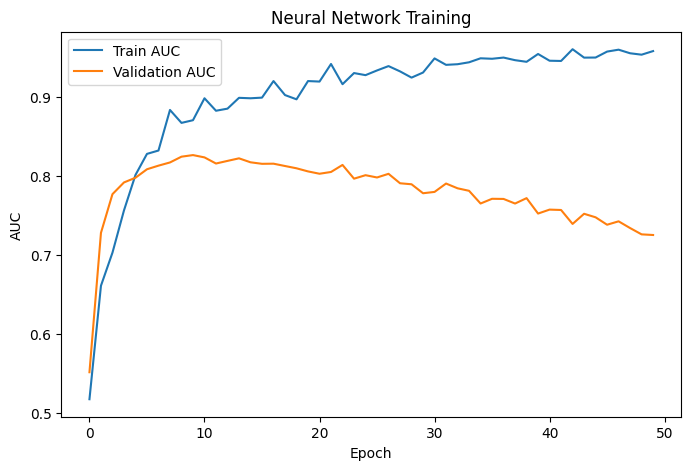

<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["AUC"], label="Train AUC")
plt.plot(history.history["val_AUC"], label="Validation AUC")

plt.title("Neural Network Training")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()

plt.show()

plt.savefig(
    "../figures/nn_training_curve.png",
    bbox_inches="tight"
)

## Key Findings

The neural network achieved the strongest fraud recall among all evaluated models.

Key observations:

- Nonlinear relationships between engineered features contributed substantially to performance.
- Class weighting successfully improved fraud sensitivity.
- The model identified fraud cases missed by multiple tree-based approaches.
- The resulting probabilities were later incorporated into ensemble experiments.